# Task 3 - Reinforcement Learning

## 1. Title and Task Definition

This notebook is the formal Task 3 reinforcement learning report for HeroBot navigation in a customised DungeonMazeWorld maze. The agent must reach the exit while dealing with sparse terminal reward, dense shaping terms, moving enemies, loop-heavy topology, and partial observability induced by ego-centric local sensing and frame stacking.

Reinforcement learning is the appropriate paradigm because the problem is sequential rather than i.i.d.: the quality of an action depends on long-horizon consequences such as whether a short detour avoids a patrol kill-zone, whether a bribable encounter unlocks a later safe route, and whether a local move leads into a dead loop several steps later. A supervised label for the optimal action is not directly available, so the agent must learn a control policy from interaction, return, and delayed credit assignment.

All tables and figures below are generated directly from the Task 3 codebase and experiment artifacts. The notebook also exposes the exact source snippets that implement the environment extensions, PPO pipeline, DQN pipeline, and curriculum schedule.

In [6]:
from pathlib import Path
import sys
import json

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

def find_task3_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start, *start.parents):
        if (candidate / 'src').exists() and (candidate / 'configs').exists() and (candidate / 'outputs').exists():
            return candidate
    raise FileNotFoundError('Could not locate task3_reinforcement root.')

TASK3_ROOT = find_task3_root()
SRC_ROOT = TASK3_ROOT / 'src'
CONFIGS = TASK3_ROOT / 'configs'
TABLES = TASK3_ROOT / 'outputs' / 'tables'
CHECKPOINTS = TASK3_ROOT / 'outputs' / 'checkpoints'
LOGS = TASK3_ROOT / 'outputs' / 'logs'

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

def load_csv(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)

def load_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

def format_pct(value):
    return f'{100 * float(value):.1f}%'

def format_float(value):
    return f'{float(value):.2f}'

def snippet(path, start, end):
    path = Path(path)
    lines = path.read_text(encoding='utf-8').splitlines()
    selected = lines[start - 1:end]
    body = '\n'.join(f'{idx:4d}: {line}' for idx, line in zip(range(start, end + 1), selected))
    return f'```python\n{body}\n```'

def show_snippet(path, start, end, title):
    display(Markdown(f'### {title}\n\n' + snippet(path, start, end)))

def prepare_progress_frame(df):
    out = df.copy()
    if 'time/total_timesteps' not in out.columns:
        out['global_timesteps'] = range(1, len(out) + 1)
        return out
    if 'phase' not in out.columns or out['time/total_timesteps'].is_monotonic_increasing:
        out['global_timesteps'] = out['time/total_timesteps']
        return out

    phase_max = out.groupby('phase')['time/total_timesteps'].max().sort_index()
    offsets = {}
    cumulative = 0
    for phase, max_step in phase_max.items():
        offsets[phase] = cumulative
        cumulative += int(max_step)

    out['global_timesteps'] = out['time/total_timesteps'] + out['phase'].map(offsets)
    return out

HERO_ENV = SRC_ROOT / 'hero_task3_env.py'
CURRICULUM = SRC_ROOT / 'curriculum_wrapper.py'
TRAIN_AGENTS = SRC_ROOT / 'train_agents.py'
RULES_FILE = TASK3_ROOT / 'TASK3_FINAL_RULES.md'

RUNS = {
    'ppo_v4': {
        'label': 'PPO v4 (Stage 6)',
        'metrics': TABLES / 'metrics_ppo_seed42_rewardH_curriculum_stage6H_curriculum.csv',
        'progress': TABLES / 'progress_ppo_seed42_rewardH_curriculum_stage6H_curriculum.csv',
        'color': '#1f77b4',
    },
    'ppo_v5_lstm': {
        'label': 'PPO v5 + LSTM (Stage 7)',
        'metrics': TABLES / 'metrics_ppo_seed42_rewardH_curriculum_stage7J_lstm.csv',
        'progress': TABLES / 'progress_ppo_seed42_rewardH_curriculum_stage7J_lstm.csv',
        'color': '#2ca02c',
    },
    'dqn_stage7_comparison': {
        'label': 'DQN Stage 7 comparison checkpoint',
        'metrics': TABLES / 'metrics_dqn_seed42_rewardH_curriculum_stage7J_dqn_stage7_comparison_50k.csv',
        'progress': TABLES / 'progress_dqn_seed42_rewardH_curriculum_stage7J_dqn_stage7_comparison_50k.csv',
        'loss': TABLES / 'loss_dqn_seed42_rewardH_curriculum_stage7J_dqn_stage7_comparison_50k.csv',
        'checkpoint': CHECKPOINTS / 'dqn_seed42_rewardH_curriculum_stage7J_dqn' / 'best_model.zip',
        'run_log': LOGS / 'run_dqn_seed42_rewardH_curriculum_stage7J_dqn_stage7_comparison_50k.json',
        'color': '#d62728',
    },
}

metrics_rows = {name: load_csv(meta['metrics']).iloc[0] for name, meta in RUNS.items()}
progress_rows = {name: load_csv(meta['progress']) for name, meta in RUNS.items()}
plot_progress_rows = {name: prepare_progress_frame(df) for name, df in progress_rows.items()}
layered_v5 = load_csv(TABLES / 'metrics_layers_ppo_seed42_rewardH_curriculum_stage7J_lstm.csv')
env_cfg = load_json(CONFIGS / 'env_stage6_rewardH.json')
ppo_cfg = load_json(CONFIGS / 'ppo.json')
dqn_cfg = load_json(CONFIGS / 'dqn_stage7_comparison.json')
dqn_loss = load_csv(RUNS['dqn_stage7_comparison']['loss'])
dqn_run_log = load_json(RUNS['dqn_stage7_comparison']['run_log'])

comparison_df = pd.DataFrame([
    {
        'Method': 'PPO v4',
        'Family': 'Policy gradient',
        'Success rate': float(metrics_rows['ppo_v4']['success_rate']),
        'Episode return': float(metrics_rows['ppo_v4']['episode_return_mean']),
        'Steps to goal': float(metrics_rows['ppo_v4']['steps_to_goal_mean']),
        'Dead-loop rate': float(metrics_rows['ppo_v4']['dead_loop_rate']),
        'Wall-collision rate': float(metrics_rows['ppo_v4']['wall_collision_case_rate']),
        'Evaluation episodes': int(metrics_rows['ppo_v4']['n_eval_episodes']),
    },
    {
        'Method': 'PPO v5 + LSTM',
        'Family': 'Recurrent policy gradient',
        'Success rate': float(metrics_rows['ppo_v5_lstm']['success_rate']),
        'Episode return': float(metrics_rows['ppo_v5_lstm']['episode_return_mean']),
        'Steps to goal': float(metrics_rows['ppo_v5_lstm']['steps_to_goal_mean']),
        'Dead-loop rate': float(metrics_rows['ppo_v5_lstm']['dead_loop_rate']),
        'Wall-collision rate': float(metrics_rows['ppo_v5_lstm']['wall_collision_case_rate']),
        'Evaluation episodes': int(metrics_rows['ppo_v5_lstm']['n_eval_episodes']),
    },
    {
        'Method': 'DQN comparison checkpoint',
        'Family': 'Value based',
        'Success rate': float(metrics_rows['dqn_stage7_comparison']['success_rate']),
        'Episode return': float(metrics_rows['dqn_stage7_comparison']['episode_return_mean']),
        'Steps to goal': float(metrics_rows['dqn_stage7_comparison']['steps_to_goal_mean']),
        'Dead-loop rate': float(metrics_rows['dqn_stage7_comparison']['dead_loop_rate']),
        'Wall-collision rate': float(metrics_rows['dqn_stage7_comparison']['wall_collision_case_rate']),
        'Evaluation episodes': int(metrics_rows['dqn_stage7_comparison']['n_eval_episodes']),
    },
])

print('Task 3 root:', TASK3_ROOT)
print('DQN comparison checkpoint:', RUNS['dqn_stage7_comparison']['checkpoint'])
print('DQN comparison run timesteps from run log:', dqn_run_log['total_timesteps'])

Task 3 root: /Users/ziyanlei/Desktop/AIR/task3_reinforcement
DQN comparison checkpoint: /Users/ziyanlei/Desktop/AIR/task3_reinforcement/outputs/checkpoints/dqn_seed42_rewardH_curriculum_stage7J_dqn/best_model.zip
DQN comparison run timesteps from run log: 50000


## 2. Algorithm Selection and Rationale

### PPO
PPO is the primary optimisation algorithm because it is an on-policy policy-gradient method with a clipped objective that stabilises updates in high-variance environments. That stability matters here: Reward H mixes small per-step shaping with sharp terminal events such as a large goal reward and severe kill-zone penalties, so policy updates need to remain robust under noisy returns. PPO is also a natural fit when the state is only partially observed from a local ego-centric tensor.

### DQN
DQN is retained as the classical off-policy value-based baseline. It provides a theoretically meaningful counterpoint because replay-buffer bootstrapping, epsilon-greedy exploration, and Q-value regression are exactly the mechanisms expected to become fragile when rewards are sparse, high variance, and delayed. In this project DQN therefore serves both as a baseline and as an empirical test of those theoretical limitations.

### Why the project emphasis moved toward PPO
The design emphasis gradually shifted toward PPO because the early DQN dynamics under the Reward H curriculum were markedly slower and more unstable than the PPO family, while the computational burden of repeated replay-buffer sampling and CNN backpropagation remained high. After the PPO line had been optimised, the project still produced a frozen DQN comparison artifact at `outputs/checkpoints/dqn_seed42_rewardH_curriculum_stage7J_dqn/best_model.zip`, and that checkpoint is evaluated below as the value-based reference. The interpretation is important: it is a real, runnable DQN model under the same Reward H curriculum contract, but it should be read as an early comparison baseline rather than as a fully converged DQN optimum.

This distinction keeps the report honest while still allowing a meaningful algorithmic comparison: PPO and recurrent PPO show what the project's main optimisation line achieved, and the frozen DQN checkpoint shows how a value-based baseline behaved under the same environment design.

## 3. Environment Modifications

The base MazeDungeon environment was extended to make the navigation task closer to a difficult sequential decision problem instead of a short deterministic path-finding toy. The final controlled comparison in this notebook uses Reward H physics together with the Stage 7 curriculum contract. In the project notes, Reward J is only a naming layer for that controlled comparison; the underlying environment still comes from `configs/env_stage6_rewardH.json`.

> The complete frozen and post-freeze rule set is recorded in `TASK3_FINAL_RULES.md`; this section only summarises the key contracts needed for the final report, especially Reward H, the Stage 7 curriculum, and the stealth-specific interaction logic.

The main modifications are: braid-maze loop carving to remove the single-solution bias, Task1 species semantics plus Task2 cluster features, ego-centric local radar observations, explicit loop and wall penalties, dynamic patrol enemies, a weapon-state channel, and frame stacking. Together these changes create partial observability, delayed credit assignment, and richer safety-efficiency trade-offs.

The next cells summarise the frozen contract and the Stage 6/Stage 7 extensions, then print the key implementation snippets from the actual source files.

In [8]:
rule_rows = [
    {
        'Component': 'Grid and topology',
        'Frozen Reward G contract': '16x16 maze with exactly five added braid loops',
        'Stage 6 / 7 use in this report': 'Same looped topology retained under Reward H',
        'Why it matters': 'Creates local ambiguity and removes the trivial single-path solution.'
    },
    {
        'Component': 'Observation',
        'Frozen Reward G contract': 'Ego-centric 4x7x7 radar with terrain, cluster radar, A* downhill mask, and breadcrumbs',
        'Stage 6 / 7 use in this report': 'Expanded to 5x7x7 with weapon state and frame_stack=3, giving an effective 15x7x7 input',
        'Why it matters': 'The agent sees only local structure, so memory and policy stability become important.'
    },
    {
        'Component': 'Entity semantics',
        'Frozen Reward G contract': 'Task1 species labels plus Task2 cluster ids with hostile and bribable routing',
        'Stage 6 / 7 use in this report': 'Retained, with bribable encounters affecting stealth progression and weapon state',
        'Why it matters': 'The same local object can imply different risk and reward trade-offs.'
    },
    {
        'Component': 'Reward and penalties',
        'Frozen Reward G contract': 'True-path shaping, wall-hit, stagnation, and dead-loop penalties plus +100 goal reward',
        'Stage 6 / 7 use in this report': 'Reward H adds kill-zone terminal penalty and keeps the small-step shaping regime',
        'Why it matters': 'Learning must balance progress, safety, and loop avoidance rather than greedily chase local reward.'
    },
    {
        'Component': 'Curriculum',
        'Frozen Reward G contract': 'Progressive spawn radius with smooth bridge stages and mixed standard starts',
        'Stage 6 / 7 use in this report': 'Same curriculum logic kept fixed for PPO and DQN comparison',
        'Why it matters': 'Makes long-horizon exploration learnable while preserving a controlled final comparison contract.'
    },
]

numeric_rows = [
    {'Parameter': 'n_virtual_entities', 'Value': env_cfg['n_virtual_entities'], 'Interpretation': 'Entity density in the maze'},
    {'Parameter': 'target_braid_loops', 'Value': env_cfg['target_braid_loops'], 'Interpretation': 'Number of guaranteed extra graph cycles'},
    {'Parameter': 'path_scale_e', 'Value': env_cfg['path_scale_e'], 'Interpretation': 'True-path shaping scale under Reward H'},
    {'Parameter': 'step_penalty_e', 'Value': env_cfg['step_penalty_e'], 'Interpretation': 'Per-step pressure to avoid wandering'},
    {'Parameter': 'wall_hit_penalty_c', 'Value': env_cfg['wall_hit_penalty_c'], 'Interpretation': 'Penalty for failed forward movement into walls'},
    {'Parameter': 'dead_loop_penalty_c', 'Value': env_cfg['dead_loop_penalty_c'], 'Interpretation': 'Penalty for repeated loop behaviour'},
    {'Parameter': 'stagnation_penalty_c', 'Value': env_cfg['stagnation_penalty_c'], 'Interpretation': 'Short-window penalty for lack of spatial progress'},
    {'Parameter': 'kill_zone_penalty_h', 'Value': env_cfg['kill_zone_penalty_h'], 'Interpretation': 'Terminal stealth penalty when a patrol kill-zone catches the agent'},
    {'Parameter': 'frame_stack', 'Value': env_cfg['frame_stack'], 'Interpretation': 'Temporal stacking factor for local radar observations'},
    {'Parameter': 'include_astar_hint', 'Value': env_cfg['include_astar_hint'], 'Interpretation': 'World-frame shortest-path guidance is enabled'},
    {'Parameter': 'include_astar_ego_hint', 'Value': env_cfg['include_astar_ego_hint'], 'Interpretation': 'Ego-frame shortest-path hint is enabled'}
]

display(Markdown('### Core rules distilled from TASK3_FINAL_RULES.md'))
display(pd.DataFrame(rule_rows))

### Core rules distilled from TASK3_FINAL_RULES.md

,Component,Frozen Reward G contract,Stage 6 / 7 use in this report,Why it matters
0,Grid and topology,16x16 maze with exactly five added braid loops,Same looped topology retained under Reward H,Creates local ambiguity and removes the trivia...
1,Observation,"Ego-centric 4x7x7 radar with terrain, cluster ...",Expanded to 5x7x7 with weapon state and frame_...,"The agent sees only local structure, so memory..."
2,Entity semantics,Task1 species labels plus Task2 cluster ids wi...,"Retained, with bribable encounters affecting s...",The same local object can imply different risk...
3,Reward and penalties,"True-path shaping, wall-hit, stagnation, and d...",Reward H adds kill-zone terminal penalty and k...,"Learning must balance progress, safety, and lo..."
4,Curriculum,Progressive spawn radius with smooth bridge st...,Same curriculum logic kept fixed for PPO and D...,Makes long-horizon exploration learnable while...


### Key Rules Extracted from TASK3_FINAL_RULES.md

The points below condense the most important clauses from `TASK3_FINAL_RULES.md` without reproducing the full document:

- **Grid topology**: the final maze is a `16x16` map whose passable graph is post-processed until it gains exactly **five genuine loops**, so the task is no longer a single-path shortest-route problem.
- **Observation contract**: the frozen reference uses an ego-centric `4x7x7` radar, while Reward H extends it to `5x7x7` and then applies `frame_stack=3`, yielding an effective `15x7x7` input tensor.
- **Channel semantics**: the channels encode terrain/boundary, Task2 entity-cluster ids, A* downhill guidance, breadcrumb memory, and under Reward H an extra weapon-state channel.
- **Entity semantics**: hostile species are `orc`, `lizard`, and `wingedrat`, while `human` and `halfling` remain bribable or neutral; entities are removed on contact to avoid repeated-cost loops.
- **Reward shaping**: the frozen contract combines true-path progress shaping with explicit penalties for wall hits, short stagnation, and dead loops, plus a `+100` success reward at the target.
- **Stealth extension**: Reward H introduces moving patrol kill-zones and a terminal `kill_zone_penalty_h=-50.0`, making the task safety-critical instead of pure path minimisation.
- **Termination logic**: an episode ends either when the target is reached or when the `256`-step horizon is exhausted; under Reward H, kill-zone capture also terminates the episode immediately.
- **Stage 7 comparison rule**: Reward J is only a label for the controlled comparison setting, meaning Reward H physics are held fixed while PPO+LSTM and DQN are compared under the same curriculum schedule.

In [9]:
display(Markdown('### Key Reward H configuration values'))
display(pd.DataFrame(numeric_rows))

show_snippet(HERO_ENV, 427, 490, 'Braid-maze post-processing: guaranteed loop creation')
show_snippet(HERO_ENV, 663, 780, 'Observation construction plus reward and interaction entry points')
show_snippet(CURRICULUM, 1, 180, 'Curriculum wrapper: progressive spawn radius, mixed starts, and bridge stages')

### Key Reward H configuration values

,Parameter,Value,Interpretation
0,n_virtual_entities,8,Entity density in the maze
1,target_braid_loops,5,Number of guaranteed extra graph cycles
2,path_scale_e,0.05,True-path shaping scale under Reward H
3,step_penalty_e,-0.03,Per-step pressure to avoid wandering
4,wall_hit_penalty_c,-1.0,Penalty for failed forward movement into walls
5,dead_loop_penalty_c,-1.5,Penalty for repeated loop behaviour
6,stagnation_penalty_c,-0.25,Short-window penalty for lack of spatial progress
7,kill_zone_penalty_h,-50.0,Terminal stealth penalty when a patrol kill-zo...
8,frame_stack,3,Temporal stacking factor for local radar obser...
9,include_astar_hint,True,World-frame shortest-path guidance is enabled


### Braid-maze post-processing: guaranteed loop creation

```python
 427:     def _carve_braid_loops(self, target_loops: int = 5) -> Tuple[int, int]:
 428:         """Open interior walls until the maze gains the requested number of graph cycles."""
 429:         start = (1, 1)
 430:         target = (self.grid_size - 2, self.grid_size - 2)
 431:         desired_loops = max(0, int(target_loops))
 432:         wall_candidates: List[Tuple[int, int]] = []
 433: 
 434:         if desired_loops <= 0:
 435:             return 0, 0
 436: 
 437:         # Only consider non-boundary interior walls to preserve physical borders.
 438:         for x in range(1, self.grid_size - 1):
 439:             for y in range(1, self.grid_size - 1):
 440:                 pos = (x, y)
 441:                 if pos == start or pos == target:
 442:                     continue
 443:                 cell = self.base_env.maze.get_cell_item(x, y)
 444:                 if cell is not None and str(getattr(cell, "type", "")) == "wall":
 445:                     wall_candidates.append(pos)
 446: 
 447:         if not wall_candidates:
 448:             return 0, 0
 449: 
 450:         candidate_order = list(wall_candidates)
 451:         self.rng.shuffle(candidate_order)
 452: 
 453:         opened_walls = 0
 454:         loops_added = 0
 455:         current_cycle_rank = self._maze_cycle_rank(target)
 456: 
 457:         # Pass 1: prefer candidates that add exactly one loop, improving map readability.
 458:         for x, y in candidate_order:
 459:             if loops_added >= desired_loops:
 460:                 break
 461:             wall_obj = self.base_env.maze.get_cell_item(x, y)
 462:             if wall_obj is None or str(getattr(wall_obj, "type", "")) != "wall":
 463:                 continue
 464: 
 465:             self.base_env.maze.add_cell_item(x, y, None)
 466:             new_cycle_rank = self._maze_cycle_rank(target)
 467:             cycle_gain = new_cycle_rank - current_cycle_rank
 468:             if cycle_gain == 1:
 469:                 opened_walls += 1
 470:                 loops_added += 1
 471:                 current_cycle_rank = new_cycle_rank
 472:             else:
 473:                 self.base_env.maze.add_cell_item(x, y, wall_obj)
 474: 
 475:         # Pass 2 fallback: allow multi-loop gains if still below target.
 476:         if loops_added < desired_loops:
 477:             for x, y in candidate_order:
 478:                 if loops_added >= desired_loops:
 479:                     break
 480:                 wall_obj = self.base_env.maze.get_cell_item(x, y)
 481:                 if wall_obj is None or str(getattr(wall_obj, "type", "")) != "wall":
 482:                     continue
 483: 
 484:                 remaining = desired_loops - loops_added
 485:                 self.base_env.maze.add_cell_item(x, y, None)
 486:                 new_cycle_rank = self._maze_cycle_rank(target)
 487:                 cycle_gain = new_cycle_rank - current_cycle_rank
 488:                 if cycle_gain > 0 and cycle_gain <= remaining:
 489:                     opened_walls += 1
 490:                     loops_added += int(cycle_gain)
```

### Observation construction plus reward and interaction entry points

```python
 663:     def _build_observation(self) -> np.ndarray:
 664:         channels = 5 if self._is_stealth_scheme() else 4
 665:         obs_dtype = np.float32 if self._is_stealth_scheme() else np.uint8
 666:         obs_matrix = np.zeros((channels, 7, 7), dtype=obs_dtype)
 667: 
 668:         target = self._pos_tuple(self.base_env.target_position)
 669:         rx, ry = self._pos_tuple(self.base_env.robot_position)
 670:         robot_t = (rx, ry)
 671: 
 672:         if not self.true_distance_map:
 673:             self.true_distance_map = self._build_true_distance_map(target)
 674:         robot_dist = self.true_distance_map.get(robot_t)
 675: 
 676:         for iy in range(7):
 677:             for ix in range(7):
 678:                 rel_right = ix - 3
 679:                 rel_forward = 3 - iy
 680:                 mx, my = self._ego_offset_to_world(rel_right=rel_right, rel_forward=rel_forward)
 681: 
 682:                 # Channel 0: terrain wall map with out-of-bounds padded as wall.
 683:                 if mx < 0 or my < 0 or mx >= self.grid_size or my >= self.grid_size:
 684:                     obs_matrix[0, iy, ix] = 1
 685:                 else:
 686:                     cell = self.base_env.maze.get_cell_item(mx, my)
 687:                     is_wall = cell is not None and str(getattr(cell, "type", "")) == "wall"
 688:                     obs_matrix[0, iy, ix] = 1 if is_wall else 0
 689: 
 690:                 # Channel 1: entity radar layer encoded as Task2 cluster ID [1..6].
 691:                 ent = self.entity_map.get((mx, my))
 692:                 if ent is not None:
 693:                     obs_matrix[1, iy, ix] = float(self._entity_cluster_id(ent.species) + 1)
 694:                 else:
 695:                     obs_matrix[1, iy, ix] = 0
 696: 
 697:                 # Channel 2: A* downhill guidance mask toward target.
 698:                 dist = self.true_distance_map.get((mx, my))
 699:                 if robot_dist is not None and dist is not None and dist <= robot_dist:
 700:                     obs_matrix[2, iy, ix] = 1
 701:                 else:
 702:                     obs_matrix[2, iy, ix] = 0
 703: 
 704:                 # Channel 3: breadcrumb memory from recent positions.
 705:                 obs_matrix[3, iy, ix] = 1 if (mx, my) in self.position_window else 0
 706: 
 707:                 if channels > 4:
 708:                     obs_matrix[4, iy, ix] = 1.0 if self.has_weapon else 0.0
 709: 
 710:         return obs_matrix.astype(obs_dtype, copy=False)
 711: 
 712:     def reset(self, *, seed: int | None = None, options: dict | None = None):
 713:         if seed is not None:
 714:             self.rng = np.random.default_rng(seed)
 715: 
 716:         self._reset_episode_stats()
 717:         self.potential_scale_multiplier = 1.0
 718:         self.base_env.reset(seed=seed, options=options)
 719:         opened_walls, braid_loops_added = self._carve_braid_loops(target_loops=self.target_braid_loops)
 720:         # Keep front-view features consistent after topology post-processing.
 721:         self.base_env.robot_camera_view = self.base_env.get_robot_camera_view()
 722:         self._spawn_virtual_entities()
 723: 
 724:         robot = self._pos_tuple(self.base_env.robot_position)
 725:         target = self._pos_tuple(self.base_env.target_position)
 726:         self.true_distance_map = self._build_true_distance_map(target)
 727:         self.prev_target_dist = float(self._manhattan(robot, target))
 728:         self.prev_true_target_dist = self._true_distance_to_target(robot, target)
 729:         self.prev_bribable_dist = self._nearest_entity_distance(robot, BRIBABLE_CLASSES)
 730: 
 731:         self.trajectory.append(robot)
 732:         self.position_window.append(robot)
 733:         self.short_position_window.append(robot)
 734: 
 735:         return self._build_observation(), {
 736:             "reward_scheme": self.reward_scheme,
 737:             "entity_count": len(self.entity_map),
 738:             "has_weapon": float(1.0 if self.has_weapon else 0.0),
 739:             "braid_opened_walls": float(opened_walls),
 740:             "braid_loops_added": float(braid_loops_added),
 741:             "braid_loop_target": float(self.target_braid_loops),
 742:         }
 743: 
 744:     def step(self, action: int):
 745:         prev_pos = self._pos_tuple(self.base_env.robot_position)
 746:         target_pos = self._pos_tuple(self.base_env.target_position)
 747: 
 748:         _, base_reward, terminated, truncated, _ = self.base_env.step(action)
 749:         reached_goal = bool(terminated)
 750:         curr_pos = self._pos_tuple(self.base_env.robot_position)
 751: 
 752:         total_reward = float(base_reward)
 753:         hit_wall = bool(int(action) == int(Actions.move_forwards) and curr_pos == prev_pos and float(base_reward) == 0.0)
 754:         if hit_wall:
 755:             self.wall_collision_count += 1
 756:             if self._uses_loop_penalties():
 757:                 total_reward += self.wall_hit_penalty_c
 758: 
 759:         killed_by = ""
 760:         if self._is_stealth_scheme() and not reached_goal:
 761:             killed, kill_bonus, killed_by = self._apply_kill_zone(curr_pos)
 762:             total_reward += kill_bonus
 763:             if killed:
 764:                 terminated = True
 765: 
 766:         ent_at_pos = self.entity_map.get(curr_pos)
 767:         if ent_at_pos is not None and not terminated:
 768:             species = ent_at_pos.species
 769:             faction = self._entity_faction(species)
 770:             if self._is_stealth_scheme():
 771:                 if faction == "bribable":
 772:                     self.bribable_contact_count += 1
 773:                     bribe_cost = self._entity_bribe_cost(species)
 774:                     self.bribe_cost_total += bribe_cost
 775:                     total_reward -= bribe_cost
 776:                     if not self.has_weapon:
 777:                         total_reward += self.bribable_contact_bonus
 778:                     self.has_weapon = True
 779:                     self._remove_entity_at(curr_pos)
 780:                 elif faction == "hostile" and species == "wingedrat" and self.has_weapon:
```

### Curriculum wrapper: progressive spawn radius, mixed starts, and bridge stages

```python
   1: from __future__ import annotations
   2: 
   3: from collections import deque
   4: from typing import Any, Dict, List, Optional, Tuple
   5: 
   6: import gymnasium as gym
   7: import numpy as np
   8: from stable_baselines3.common.callbacks import BaseCallback
   9: 
  10: from entity_inference import BRIBABLE_CLASSES
  11: from hero_task3_env import HeroTask3Env
  12: 
  13: 
  14: class CurriculumWrapper(gym.Wrapper):
  15:     def __init__(
  16:         self,
  17:         env: HeroTask3Env,
  18:         initial_level: int = 1,
  19:         radius_step: int = 5,
  20:         success_window: int = 50,
  21:         levelup_threshold: float = 0.7,
  22:         train_fixed_level: int = 0,
  23:         mixed_sampling_enabled: bool = False,
  24:         standard_start_ratio: float = 0.2,
  25:         standard_potential_multiplier: float = 1.5,
  26:         smooth_bridge_from_level: int = 2,
  27:         smooth_bridge_to_level: int = 3,
  28:         smooth_bridge_stages: int = 4,
  29:         max_level: Optional[int] = None,
  30:     ) -> None:
  31:         super().__init__(env)
  32:         self.initial_level = max(1, int(initial_level))
  33:         self.level = self.initial_level
  34:         self.radius_step = max(1, int(radius_step))
  35:         self.success_window = max(1, int(success_window))
  36:         self.levelup_threshold = float(levelup_threshold)
  37:         self.train_fixed_level = max(0, int(train_fixed_level))
  38:         self.mixed_sampling_enabled = bool(mixed_sampling_enabled)
  39:         self.standard_start_ratio = float(np.clip(float(standard_start_ratio), 0.0, 1.0))
  40:         self.current_standard_start_ratio = float(self.standard_start_ratio)
  41:         self.standard_potential_multiplier = max(1.0, float(standard_potential_multiplier))
  42:         self.smooth_bridge_from_level = int(smooth_bridge_from_level)
  43:         self.smooth_bridge_to_level = int(smooth_bridge_to_level)
  44:         self.smooth_bridge_stages = max(0, int(smooth_bridge_stages))
  45: 
  46:         goal = (self.env.grid_size - 2, self.env.grid_size - 2)
  47:         start = (1, 1)
  48:         full_start_distance = abs(goal[0] - start[0]) + abs(goal[1] - start[1])
  49:         computed_max_level = int(np.ceil(full_start_distance / float(self.radius_step)))
  50:         self.max_level = int(max_level) if max_level is not None else max(1, computed_max_level)
  51: 
  52:         if self.train_fixed_level > 0:
  53:             self.level = int(np.clip(self.train_fixed_level, 1, self.max_level))
  54:         self.fixed_start_mode = self.level >= self.max_level and self.train_fixed_level <= 0
  55:         self.recent_success: deque[float] = deque(maxlen=self.success_window)
  56:         self.episodes_seen = 0
  57:         self.level_up_events: List[Dict[str, Any]] = []
  58:         self.standard_ratio_boost_events: List[Dict[str, Any]] = []
  59:         self.bridge_stage = 0
  60:         self.last_sampled_standard_start = False
  61: 
  62:     def _effective_radius(self) -> int:
  63:         base_radius = int(self.level * self.radius_step)
  64:         if (
  65:             self.smooth_bridge_stages > 0
  66:             and self.level == self.smooth_bridge_from_level
  67:             and self.smooth_bridge_to_level == self.smooth_bridge_from_level + 1
  68:         ):
  69:             max_bonus = max(0, self.radius_step - 1)
  70:             bonus = int(np.clip(self.bridge_stage, 0, max_bonus))
  71:             return base_radius + bonus
  72:         return base_radius
  73: 
  74:     def _curriculum_info(self) -> Dict[str, float]:
  75:         return {
  76:             "curriculum_level": float(self.level),
  77:             "curriculum_bridge_stage": float(self.bridge_stage),
  78:             "curriculum_effective_radius": float(self._effective_radius()),
  79:             "curriculum_recent_success_rate": float(np.mean(self.recent_success)) if self.recent_success else 0.0,
  80:             "curriculum_fixed_start": float(1.0 if self.fixed_start_mode else 0.0),
  81:             "curriculum_sample_standard_start": float(1.0 if self.last_sampled_standard_start else 0.0),
  82:             "curriculum_standard_start_ratio": float(self.current_standard_start_ratio),
  83:         }
  84: 
  85:     def _all_spawn_candidates(self, radius: int) -> List[Tuple[int, int]]:
  86:         target = tuple(map(int, self.env.base_env.target_position.tolist()))
  87:         candidates: List[Tuple[int, int]] = []
  88: 
  89:         for x in range(1, self.env.grid_size - 1):
  90:             for y in range(1, self.env.grid_size - 1):
  91:                 if (x, y) == target:
  92:                     continue
  93:                 cell = self.env.base_env.maze.get_cell_item(x, y)
  94:                 if cell is not None:
  95:                     continue
  96:                 dist = abs(x - target[0]) + abs(y - target[1])
  97:                 if dist <= radius:
  98:                     candidates.append((x, y))
  99: 
 100:         return candidates
 101: 
 102:     def _set_spawn(self, spawn_pos: Tuple[int, int]) -> None:
 103:         x, y = spawn_pos
 104:         self.env.base_env.robot_position = np.array([x, y], dtype=int)
 105:         self.env.base_env.robot_direction = 2
 106:         self.env.base_env.robot_camera_view = self.env.base_env.get_robot_camera_view()
 107: 
 108:         # Ensure spawned cell is not occupied by a virtual entity.
 109:         if hasattr(self.env, "_remove_entity_at"):
 110:             self.env._remove_entity_at((x, y))
 111:         else:
 112:             self.env.entity_map.pop((x, y), None)
 113: 
 114:         target = tuple(map(int, self.env.base_env.target_position.tolist()))
 115:         self.env.prev_target_dist = float(abs(x - target[0]) + abs(y - target[1]))
 116:         if hasattr(self.env, "_true_distance_to_target"):
 117:             self.env.prev_true_target_dist = float(self.env._true_distance_to_target((x, y), target))
 118:         self.env.prev_bribable_dist = self.env._nearest_entity_distance((x, y), BRIBABLE_CLASSES)
 119: 
 120:         self.env.trajectory = [(x, y)]
 121:         self.env.position_window.clear()
 122:         self.env.position_window.append((x, y))
 123:         self.env.short_position_window.clear()
 124:         self.env.short_position_window.append((x, y))
 125: 
 126:     def reset(self, *, seed: int | None = None, options: dict | None = None):
 127:         options = options or {}
 128:         forced_level = options.get("curriculum_level")
 129:         freeze_curriculum = bool(options.get("freeze_curriculum", False))
 130:         force_standard_start = bool(options.get("force_standard_start", False))
 131: 
 132:         obs, info = self.env.reset(seed=seed, options=options)
 133: 
 134:         # Force fixed-level curriculum for pretraining stage.
 135:         if forced_level is None and self.train_fixed_level > 0:
 136:             forced_level = int(np.clip(self.train_fixed_level, 1, self.max_level))
 137:             freeze_curriculum = True
 138:             self.fixed_start_mode = False
 139: 
 140:         sampled_standard_start = False
 141:         if forced_level is None and force_standard_start:
 142:             sampled_standard_start = True
 143:         elif (
 144:             forced_level is None
 145:             and self.mixed_sampling_enabled
 146:             and self.train_fixed_level <= 0
 147:             and not self.fixed_start_mode
 148:         ):
 149:             sampled_standard_start = bool(self.env.rng.random() < self.current_standard_start_ratio)
 150: 
 151:         if sampled_standard_start:
 152:             self.last_sampled_standard_start = True
 153:             self.env.potential_scale_multiplier = float(self.standard_potential_multiplier)
 154:             info.update(self._curriculum_info())
 155:             return obs, info
 156: 
 157:         # Switch to standard starting-point mode when level is high enough.
 158:         if self.fixed_start_mode and forced_level is None:
 159:             self.last_sampled_standard_start = True
 160:             self.env.potential_scale_multiplier = float(self.standard_potential_multiplier)
 161:             info.update(self._curriculum_info())
 162:             return obs, info
 163: 
 164:         level_to_use = int(forced_level) if forced_level is not None else int(self.level)
 165:         if level_to_use >= self.max_level and not freeze_curriculum:
 166:             self.fixed_start_mode = True
 167:             self.level = self.max_level
 168:             self.last_sampled_standard_start = True
 169:             self.env.potential_scale_multiplier = float(self.standard_potential_multiplier)
 170:             info.update(self._curriculum_info())
 171:             return obs, info
 172: 
 173:         radius = int(level_to_use * self.radius_step)
 174:         if (
 175:             forced_level is None
 176:             and self.smooth_bridge_stages > 0
 177:             and level_to_use == self.smooth_bridge_from_level
 178:             and self.smooth_bridge_to_level == self.smooth_bridge_from_level + 1
 179:         ):
 180:             radius = self._effective_radius()
```

In [3]:
hyperparams_df = pd.DataFrame([
    {
        'Setting': 'Observation tensor',
        'PPO family': '15x7x7 under Reward H',
        'DQN comparison': '15x7x7 under Reward H',
        'Comment': '5 radar channels with frame_stack=3'
    },
    {
        'Setting': 'Learning rate',
        'PPO family': f"{ppo_cfg['learning_rate_start']} -> {ppo_cfg['learning_rate_end']}",
        'DQN comparison': f"{dqn_cfg['learning_rate_start']} -> {dqn_cfg['learning_rate_end']}",
        'Comment': 'Both families use explicit decay rather than a fixed scalar'
    },
    {
        'Setting': 'Batch size',
        'PPO family': int(ppo_cfg['batch_size']),
        'DQN comparison': int(dqn_cfg['batch_size']),
        'Comment': 'Shared mini-batch scale helps comparison'
    },
    {
        'Setting': 'Discount factor gamma',
        'PPO family': ppo_cfg['gamma'],
        'DQN comparison': dqn_cfg['gamma'],
        'Comment': 'Both algorithms optimise long-horizon return'
    },
    {
        'Setting': 'Policy update control',
        'PPO family': f"clip_range={ppo_cfg['clip_range']}, n_steps={ppo_cfg['n_steps']}, n_epochs={ppo_cfg['n_epochs']}",
        'DQN comparison': 'Off-policy TD updates, no clipped surrogate objective',
        'Comment': 'PPO explicitly constrains policy movement per update'
    },
    {
        'Setting': 'Replay / exploration',
        'PPO family': 'On-policy rollouts, entropy scheduling',
        'DQN comparison': f"buffer {dqn_cfg['buffer_size_start']} -> {dqn_cfg['buffer_size_end']}, eps {dqn_cfg['exploration_fraction']} -> {dqn_cfg['exploration_final_eps']}",
        'Comment': 'DQN depends on replay and epsilon-greedy exploration'
    },
    {
        'Setting': 'Memory mechanism',
        'PPO family': 'Stage 7 uses RecurrentPPO with CnnLstmPolicy and TinyCNN',
        'DQN comparison': 'No recurrent memory in the comparison checkpoint',
        'Comment': 'This is the main architectural change between v4 and v5 PPO'
    }
])

display(pd.DataFrame(hyperparams_df))

show_snippet(TRAIN_AGENTS, 204, 245, 'TinyCNN feature extractor shared by PPO and DQN')
show_snippet(TRAIN_AGENTS, 430, 472, 'DQN construction: replay buffer, epsilon schedule, staged decay, and logging')
show_snippet(TRAIN_AGENTS, 500, 560, 'PPO / RecurrentPPO construction: clipped policy optimisation with optional LSTM memory')

,Setting,PPO family,DQN comparison,Comment
0,Observation tensor,15x7x7 under Reward H,15x7x7 under Reward H,5 radar channels with frame_stack=3
1,Learning rate,0.0003 -> 5e-05,0.0003 -> 5e-05,Both families use explicit decay rather than a...
2,Batch size,256,256,Shared mini-batch scale helps comparison
3,Discount factor gamma,0.99,0.99,Both algorithms optimise long-horizon return
4,Policy update control,"clip_range=0.2, n_steps=2048, n_epochs=10","Off-policy TD updates, no clipped surrogate ob...",PPO explicitly constrains policy movement per ...
5,Replay / exploration,"On-policy rollouts, entropy scheduling","buffer 100000 -> 50000, eps 0.15 -> 0.03",DQN depends on replay and epsilon-greedy explo...
6,Memory mechanism,Stage 7 uses RecurrentPPO with CnnLstmPolicy a...,No recurrent memory in the comparison checkpoint,This is the main architectural change between ...


### TinyCNN feature extractor shared by PPO and DQN

```python
 204: class TinyCNN(BaseFeaturesExtractor):
 205:     """Lightweight CNN features extractor for stacked 7x7 radar observations."""
 206: 
 207:     def __init__(self, observation_space: gym.spaces.Box, features_dim: int = 512) -> None:
 208:         super().__init__(observation_space, features_dim)
 209:         n_input_channels = int(observation_space.shape[0])
 210: 
 211:         self.cnn = nn.Sequential(
 212:             nn.Conv2d(in_channels=n_input_channels, out_channels=32, kernel_size=3, stride=1, padding=1),
 213:             nn.ReLU(),
 214:             nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
 215:             nn.ReLU(),
 216:             nn.Flatten(),
 217:         )
 218: 
 219:         with th.no_grad():
 220:             sample = th.as_tensor(observation_space.sample()[None]).float()
 221:             n_flatten = int(self.cnn(sample).shape[1])
 222: 
 223:         self.linear = nn.Sequential(
 224:             nn.Linear(n_flatten, features_dim),
 225:             nn.ReLU(),
 226:         )
 227: 
 228:     def forward(self, observations: th.Tensor) -> th.Tensor:
 229:         return self.linear(self.cnn(observations.float()))
 230: 
 231: 
 232: def _build_dqn_decay_plan(config: Dict[str, Any], total_timesteps: int) -> List[Dict[str, Any]]:
 233:     phases = int(config.get("decay_phases", 4))
 234:     phases = max(1, phases)
 235: 
 236:     lr_start = float(config.get("learning_rate_start", config.get("learning_rate", 1e-4)))
 237:     lr_end = float(config.get("learning_rate_end", lr_start))
 238: 
 239:     buffer_start = int(config.get("buffer_size_start", config.get("buffer_size", 200_000)))
 240:     buffer_end = int(config.get("buffer_size_end", buffer_start))
 241:     batch_size = int(config.get("batch_size", 256))
 242: 
 243:     steps = [total_timesteps // phases] * phases
 244:     for i in range(total_timesteps % phases):
 245:         steps[i] += 1
```

### DQN construction: replay buffer, epsilon schedule, staged decay, and logging

```python
 430:             phase_buffer = int(phase_cfg["buffer_size"])
 431: 
 432:             model_kwargs = {
 433:                 "policy": "CnnPolicy",
 434:                 "env": env,
 435:                 "seed": seed,
 436:                 "policy_kwargs": dqn_policy_kwargs,
 437:                 "learning_rate": phase_lr,
 438:                 "buffer_size": phase_buffer,
 439:                 "batch_size": int(config.get("batch_size", 256)),
 440:                 "gamma": float(config.get("gamma", 0.99)),
 441:                 "train_freq": int(config.get("train_freq", 4)),
 442:                 "target_update_interval": int(config.get("target_update_interval", 5000)),
 443:                 "exploration_fraction": float(config.get("exploration_fraction", 0.45)),
 444:                 "exploration_final_eps": float(config.get("exploration_final_eps", 0.08)),
 445:                 "gradient_steps": int(config.get("gradient_steps", 1)),
 446:                 "device": device,
 447:                 "verbose": 0,
 448:             }
 449: 
 450:             if model is None:
 451:                 model = DQN(**model_kwargs)
 452:             else:
 453:                 next_model = DQN(**model_kwargs)
 454:                 next_model.policy.load_state_dict(model.policy.state_dict())
 455:                 model = next_model
 456: 
 457:             logger_dir = logs_dir / f"sb3_{run_tag}_phase{phase_id}"
 458:             ensure_dirs(logger_dir)
 459:             model.set_logger(configure(str(logger_dir), ["csv", "tensorboard"]))
 460: 
 461:             model.learn(
 462:                 total_timesteps=phase_steps,
 463:                 reset_num_timesteps=(phase_id == 1),
 464:                 progress_bar=False,
 465:                 callback=callback,
 466:             )
 467: 
 468:             progress_path = logger_dir / "progress.csv"
 469:             phase_df = _safe_read_csv(progress_path)
 470:             if not phase_df.empty:
 471:                 phase_df["phase"] = phase_id
 472:                 phase_df["phase_learning_rate"] = phase_lr
```

### PPO / RecurrentPPO construction: clipped policy optimisation with optional LSTM memory

```python
 500:             "ppo_ent_coef_phases": ent_phases,
 501:         }
 502: 
 503:         loaded_from_checkpoint = False
 504:         policy_kwargs: Dict[str, Any] = {
 505:             "features_extractor_class": TinyCNN,
 506:             "features_extractor_kwargs": {"features_dim": 512},
 507:             "normalize_images": False,
 508:         }
 509:         if use_recurrent:
 510:             policy_kwargs["lstm_hidden_size"] = int(lstm_hidden_size)
 511:             policy_kwargs["n_lstm_layers"] = int(n_lstm_layers)
 512:             policy_kwargs["enable_critic_lstm"] = True
 513:             decay_info["recurrent"] = True
 514:             decay_info["lstm_hidden_size"] = int(lstm_hidden_size)
 515:             decay_info["n_lstm_layers"] = int(n_lstm_layers)
 516: 
 517:         algo_cls = RecurrentPPO if use_recurrent else PPO
 518:         algo_policy = "CnnLstmPolicy" if use_recurrent else "CnnPolicy"
 519:         if init_model_path is not None:
 520:             checkpoint_path = Path(init_model_path).resolve()
 521:             if not checkpoint_path.exists():
 522:                 raise FileNotFoundError(f"init model not found: {checkpoint_path}")
 523:             custom_objects = {
 524:                 "policy_kwargs": policy_kwargs,
 525:             }
 526:             model = algo_cls.load(str(checkpoint_path), env=env, device=device, custom_objects=custom_objects)
 527:             loaded_from_checkpoint = True
 528:         else:
 529:             model = algo_cls(
 530:                 algo_policy,
 531:                 env,
 532:                 seed=seed,
 533:                 policy_kwargs=policy_kwargs,
 534:                 learning_rate=lr_schedule,
 535:                 n_steps=int(config.get("n_steps", 2048)),
 536:                 batch_size=int(config.get("batch_size", 256)),
 537:                 n_epochs=int(config.get("n_epochs", 10)),
 538:                 gamma=float(config.get("gamma", 0.99)),
 539:                 gae_lambda=float(config.get("gae_lambda", 0.95)),
 540:                 clip_range=float(config.get("clip_range", 0.2)),
 541:                 ent_coef=ent_start,
 542:                 device=device,
 543:                 verbose=0,
 544:             )
 545: 
 546:         for phase_id, phase_steps_i in enumerate(phase_steps, start=1):
 547:             if eval_only:
 548:                 break
 549:             alpha = float((phase_id - 1) / (ent_phases - 1)) if ent_phases > 1 else 0.0
 550:             phase_ent = float(ent_start + (ent_end - ent_start) * alpha)
 551:             model.ent_coef = phase_ent
 552: 
 553:             logger_dir = logs_dir / f"sb3_{run_tag}_phase{phase_id}"
 554:             ensure_dirs(logger_dir)
 555:             model.set_logger(configure(str(logger_dir), ["csv"]))
 556: 
 557:             model.learn(
 558:                 total_timesteps=int(phase_steps_i),
 559:                 reset_num_timesteps=(phase_id == 1 and not loaded_from_checkpoint),
 560:                 progress_bar=False,
```

## 5. Design Choices and Experimental Evolution

The strongest part of the project is not a single final metric but the evidence-driven evolution of the design. Earlier Reward A and Reward B experiments established the failure baseline: the problem remained effectively unsolved under sparse reward and naïve dense shaping. Subsequent Reward C, E, F, and F2 experiments isolated why learning was difficult, namely weak long-horizon guidance, insufficient loop awareness, and the burden of converting world-frame guidance into ego-centric actions.

Reward G then froze a cleaner CNN contract: ego-centric radar, Task2 entity-cluster encoding, braid topology, and explicit penalties for wall hits, stagnation, and dead loops. Stage 6 Reward H raised the task difficulty again by adding moving kill-zones, weapon-state observation, and frame stacking. The Stage 6 PPO v4 line provided the first strong stealth-navigation baseline. Stage 7 then introduced recurrent memory, which is the main reason the PPO line improved further.

DQN was kept in the loop as a genuine value-based baseline. Its role became diagnostic as well as comparative: the early comparison checkpoint gives concrete evidence that value bootstrapping struggled under the same Reward H curriculum, especially in dead-loop control and collision avoidance. The plots below make that transition visible.

,Date,Stage,Evidence,Design decision
0,2026-04-18,Early diagnostic rewards A / B,Zero-success baseline from the broader design ...,Need stronger shaping and better local state r...
1,2026-04-19 to 2026-04-22,Reward C / E / F / F2,Path shaping and A* hints broke the failure pa...,Freeze a clearer CNN contract and strengthen t...
2,2026-04-26,Reward G frozen contract,"Ego-centric radar, cluster channel, braid loop...",Use Reward G as the controlled reference befor...
3,2026-04-27,Stage 6 PPO v4,"success_rate=0.32, dead_loop_rate=0.04","Reward H with curriculum is workable, but memo..."
4,2026-04-30,Stage 7 PPO v5 + LSTM,"success_rate=0.41, standard_start=0.33",Recurrent memory improves the controlled Stage...
5,2026-04-30,Stage 7 DQN comparison checkpoint,"success_rate=0.26, dead_loop_rate=0.52",Keep DQN as a value-based reference but priori...


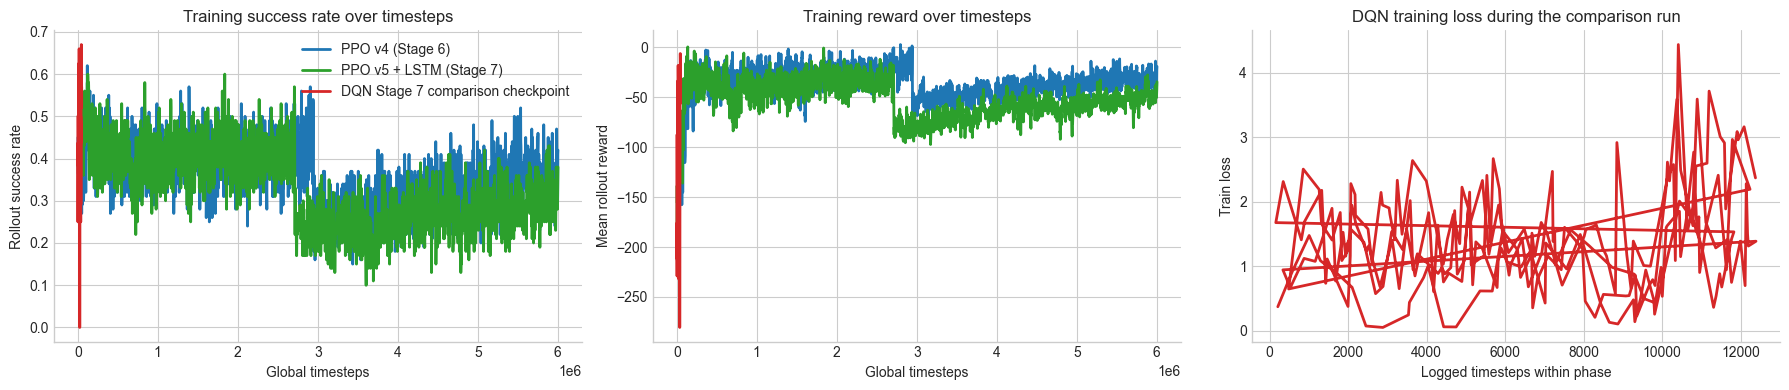

### DQN comparison-run snapshot

,Checkpoint role,Best model path,Run-log timesteps,Last plotted global timestep,Final training-window success rate,Final exploration rate,Last decay phase
0,Frozen value-based comparison artifact,/Users/ziyanlei/Desktop/AIR/task3_reinforcemen...,50000,48817,0.55,0.03,4


In [10]:
evolution_df = pd.DataFrame([
    {
        'Date': '2026-04-18',
        'Stage': 'Early diagnostic rewards A / B',
        'Evidence': 'Zero-success baseline from the broader design history',
        'Design decision': 'Need stronger shaping and better local state representation'
    },
    {
        'Date': '2026-04-19 to 2026-04-22',
        'Stage': 'Reward C / E / F / F2',
        'Evidence': 'Path shaping and A* hints broke the failure pattern but long-horizon generalisation remained weak',
        'Design decision': 'Freeze a clearer CNN contract and strengthen topology / penalties'
    },
    {
        'Date': '2026-04-26',
        'Stage': 'Reward G frozen contract',
        'Evidence': 'Ego-centric radar, cluster channel, braid loops, and explicit penalties became stable design primitives',
        'Design decision': 'Use Reward G as the controlled reference before stealth extensions'
    },
    {
        'Date': '2026-04-27',
        'Stage': 'Stage 6 PPO v4',
        'Evidence': f"success_rate={metrics_rows['ppo_v4']['success_rate']:.2f}, dead_loop_rate={metrics_rows['ppo_v4']['dead_loop_rate']:.2f}",
        'Design decision': 'Reward H with curriculum is workable, but memory and partial observability remain bottlenecks'
    },
    {
        'Date': '2026-04-30',
        'Stage': 'Stage 7 PPO v5 + LSTM',
        'Evidence': f"success_rate={metrics_rows['ppo_v5_lstm']['success_rate']:.2f}, standard_start={layered_v5[layered_v5['layer'] == 'standard_start']['success_rate'].iloc[0]:.2f}",
        'Design decision': 'Recurrent memory improves the controlled Stage 7 line'
    },
    {
        'Date': '2026-04-30',
        'Stage': 'Stage 7 DQN comparison checkpoint',
        'Evidence': f"success_rate={metrics_rows['dqn_stage7_comparison']['success_rate']:.2f}, dead_loop_rate={metrics_rows['dqn_stage7_comparison']['dead_loop_rate']:.2f}",
        'Design decision': 'Keep DQN as a value-based reference but prioritise deeper PPO optimisation'
    }
])

display(evolution_df[['Date', 'Stage', 'Evidence', 'Design decision']])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for name, meta in RUNS.items():
    df = plot_progress_rows[name]
    axes[0].plot(df['global_timesteps'], df['rollout/success_rate'], label=meta['label'], color=meta['color'], linewidth=2)
    axes[1].plot(df['global_timesteps'], df['rollout/ep_rew_mean'], label=meta['label'], color=meta['color'], linewidth=2)

axes[0].set_title('Training success rate over timesteps')
axes[0].set_xlabel('Global timesteps')
axes[0].set_ylabel('Rollout success rate')
axes[0].legend()

axes[1].set_title('Training reward over timesteps')
axes[1].set_xlabel('Global timesteps')
axes[1].set_ylabel('Mean rollout reward')

axes[2].plot(dqn_loss['time/total_timesteps'], dqn_loss['train/loss'], color=RUNS['dqn_stage7_comparison']['color'], linewidth=2)
axes[2].set_title('DQN training loss during the comparison run')
axes[2].set_xlabel('Logged timesteps within phase')
axes[2].set_ylabel('Train loss')

plt.tight_layout()
plt.show()

dqn_snapshot = pd.DataFrame([
    {
        'Checkpoint role': 'Frozen value-based comparison artifact',
        'Best model path': str(RUNS['dqn_stage7_comparison']['checkpoint']),
        'Run-log timesteps': int(dqn_run_log['total_timesteps']),
        'Last plotted global timestep': int(plot_progress_rows['dqn_stage7_comparison']['global_timesteps'].iloc[-1]),
        'Final training-window success rate': float(progress_rows['dqn_stage7_comparison']['rollout/success_rate'].iloc[-1]),
        'Final exploration rate': float(progress_rows['dqn_stage7_comparison']['rollout/exploration_rate'].dropna().iloc[-1]),
        'Last decay phase': int(progress_rows['dqn_stage7_comparison']['phase'].iloc[-1]),
    }
])

display(Markdown('### DQN comparison-run snapshot'))
display(dqn_snapshot)

## 6. Evaluation and Comparison

The evaluation emphasises success rate, episode return, steps to goal, dead-loop rate, and wall-collision case rate. Success rate is the primary task objective because reaching the exit is the real goal. Episode return matters because Reward H mixes progress shaping and safety penalties, so it reflects whether the policy is merely surviving or actually solving the task efficiently. Steps to goal quantify route efficiency among successful episodes, while dead-loop and wall-collision rates diagnose failure mode quality rather than treating all failures as equivalent.

Two comparison levels are needed. First, the PPO family should be compared internally to show what the design iterations achieved. Second, the final three-way table should contrast PPO v4, PPO v5 + LSTM, and the DQN comparison artifact under the same Reward H contract. The DQN row is useful because it highlights not only lower success, but also qualitatively different failure behaviour.

### PPO family comparison

,Method,Family,Success rate,Episode return,Steps to goal,Dead-loop rate,Wall-collision rate,Evaluation episodes
0,PPO v4,Policy gradient,32.0%,-49.31,44.44,4.0%,2.0%,100
1,PPO v5 + LSTM,Recurrent policy gradient,41.0%,-44.34,54.90,15.0%,5.0%,100


### Final three-way comparison

,Method,Family,Success rate,Episode return,Steps to goal,Dead-loop rate,Wall-collision rate,Evaluation episodes
0,PPO v4,Policy gradient,32.0%,-49.31,44.44,4.0%,2.0%,100
1,PPO v5 + LSTM,Recurrent policy gradient,41.0%,-44.34,54.90,15.0%,5.0%,100
2,DQN comparison checkpoint,Value based,26.0%,-183.13,89.54,52.0%,58.0%,50


### Key deltas

,Comparison,Success-rate delta,Return delta,Dead-loop delta
0,PPO v5 vs PPO v4,9.0%,4.96,11.0%
1,PPO v5 vs DQN comparison,15.0%,138.78,-37.0%


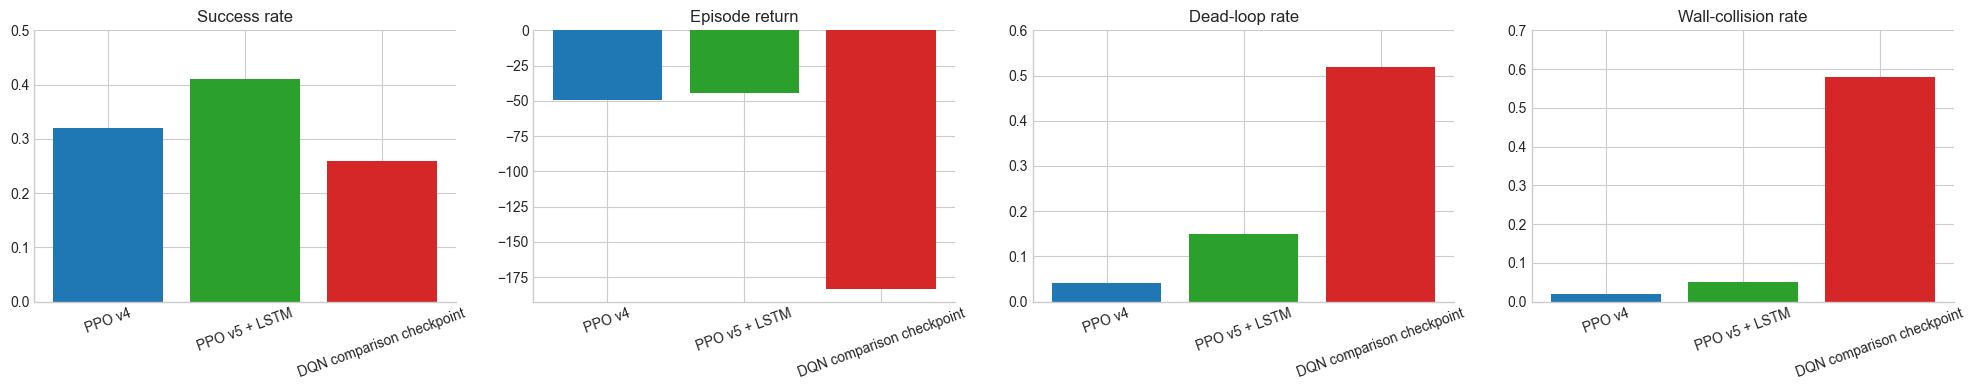

### Layered curriculum evaluation for PPO v5 + LSTM

,Evaluation slice,Success rate,Episode return,episode_return_std,Steps mean,Dead-loop rate,Wall-collision rate,n_eval_episodes
0,k1,91.0%,81.67,44.360676,4.67,0.0%,0.0%,100
1,k2,81.0%,57.66,94.314454,10.07,1.0%,1.0%,100
2,k3,73.0%,35.46,120.224226,16.15,3.0%,2.0%,100
3,standard_start,33.0%,-43.84,87.409047,36.26,11.0%,8.0%,100


In [11]:
ppo_internal_df = comparison_df[comparison_df['Method'].isin(['PPO v4', 'PPO v5 + LSTM'])].copy()
ppo_internal_df['Success rate'] = ppo_internal_df['Success rate'].map(format_pct)
ppo_internal_df['Episode return'] = ppo_internal_df['Episode return'].map(format_float)
ppo_internal_df['Steps to goal'] = ppo_internal_df['Steps to goal'].map(format_float)
ppo_internal_df['Dead-loop rate'] = ppo_internal_df['Dead-loop rate'].map(format_pct)
ppo_internal_df['Wall-collision rate'] = ppo_internal_df['Wall-collision rate'].map(format_pct)

display(Markdown('### PPO family comparison'))
display(ppo_internal_df)

three_way_df = comparison_df.copy()
three_way_df['Success rate'] = three_way_df['Success rate'].map(format_pct)
three_way_df['Episode return'] = three_way_df['Episode return'].map(format_float)
three_way_df['Steps to goal'] = three_way_df['Steps to goal'].map(format_float)
three_way_df['Dead-loop rate'] = three_way_df['Dead-loop rate'].map(format_pct)
three_way_df['Wall-collision rate'] = three_way_df['Wall-collision rate'].map(format_pct)

display(Markdown('### Final three-way comparison'))
display(three_way_df)

delta_df = pd.DataFrame([
    {
        'Comparison': 'PPO v5 vs PPO v4',
        'Success-rate delta': metrics_rows['ppo_v5_lstm']['success_rate'] - metrics_rows['ppo_v4']['success_rate'],
        'Return delta': metrics_rows['ppo_v5_lstm']['episode_return_mean'] - metrics_rows['ppo_v4']['episode_return_mean'],
        'Dead-loop delta': metrics_rows['ppo_v5_lstm']['dead_loop_rate'] - metrics_rows['ppo_v4']['dead_loop_rate'],
    },
    {
        'Comparison': 'PPO v5 vs DQN comparison',
        'Success-rate delta': metrics_rows['ppo_v5_lstm']['success_rate'] - metrics_rows['dqn_stage7_comparison']['success_rate'],
        'Return delta': metrics_rows['ppo_v5_lstm']['episode_return_mean'] - metrics_rows['dqn_stage7_comparison']['episode_return_mean'],
        'Dead-loop delta': metrics_rows['ppo_v5_lstm']['dead_loop_rate'] - metrics_rows['dqn_stage7_comparison']['dead_loop_rate'],
    }
])
delta_df['Success-rate delta'] = delta_df['Success-rate delta'].map(format_pct)
delta_df['Return delta'] = delta_df['Return delta'].map(format_float)
delta_df['Dead-loop delta'] = delta_df['Dead-loop delta'].map(format_pct)
display(Markdown('### Key deltas'))
display(delta_df)

plot_df = comparison_df.copy()
colors = [RUNS['ppo_v4']['color'], RUNS['ppo_v5_lstm']['color'], RUNS['dqn_stage7_comparison']['color']]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
metric_columns = ['Success rate', 'Episode return', 'Dead-loop rate', 'Wall-collision rate']
for ax, col in zip(axes, metric_columns):
    ax.bar(plot_df['Method'], plot_df[col], color=colors)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=20)

axes[0].set_ylim(0, 0.5)
axes[2].set_ylim(0, 0.6)
axes[3].set_ylim(0, 0.7)
plt.tight_layout()
plt.show()

layered_display = layered_v5.rename(columns={
    'layer': 'Evaluation slice',
    'success_rate': 'Success rate',
    'episode_return_mean': 'Episode return',
    'steps_mean': 'Steps mean',
    'dead_loop_rate': 'Dead-loop rate',
    'wall_collision_case_rate': 'Wall-collision rate',
}).copy()
layered_display['Success rate'] = layered_display['Success rate'].map(format_pct)
layered_display['Episode return'] = layered_display['Episode return'].map(format_float)
layered_display['Steps mean'] = layered_display['Steps mean'].map(format_float)
layered_display['Dead-loop rate'] = layered_display['Dead-loop rate'].map(format_pct)
layered_display['Wall-collision rate'] = layered_display['Wall-collision rate'].map(format_pct)

display(Markdown('### Layered curriculum evaluation for PPO v5 + LSTM'))
display(layered_display)

### 6.1 Training Policy Visual Demonstration

The following GIFs show the trained Stage 7 PPO+LSTM policy using the final standard-start slice of the curriculum. Both files come from the same successful rollout and are rendered in two visual styles so that the navigation behaviour is easy to inspect without changing the underlying trajectory.

#### Marker-style rollout

Curriculum slice: standard_start. This is the final Stage 7 successful rollout rendered with markers, showing the policy after the curriculum has already expanded beyond the local k1-k3 stages into the full start distribution.

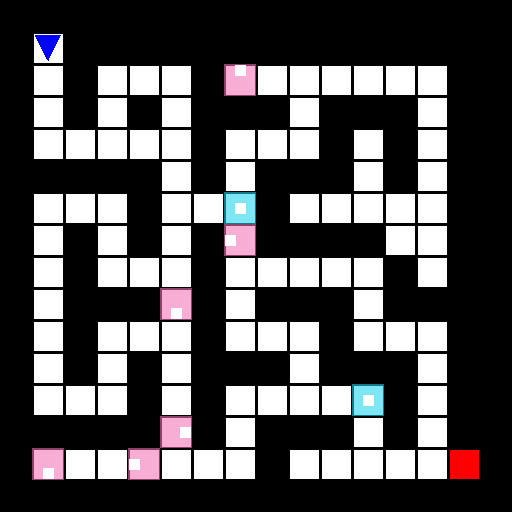

#### Sprite-style rollout

Curriculum slice: standard_start. This is the same trained policy and the same successful rollout rendered with sprites for a more game-like visual interpretation.

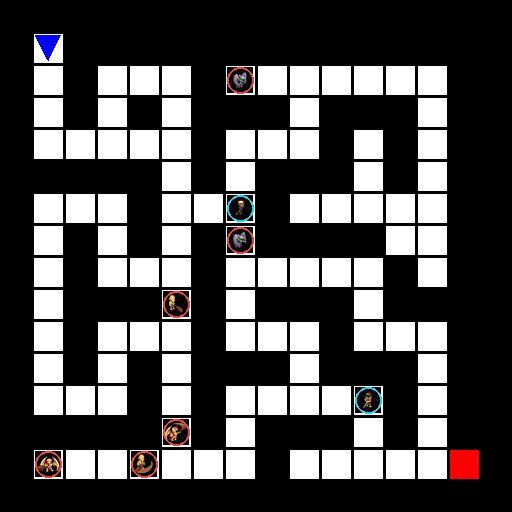

In [12]:
from IPython.display import Image

notebook_dir = TASK3_ROOT / 'notebooks'
gif_specs = [
    {
        'title': 'Marker-style rollout',
        'path': (notebook_dir / '../outputs/figures/stage7_lstm_standard_markers.gif').resolve(),
        'caption': 'Curriculum slice: standard_start. This is the final Stage 7 successful rollout rendered with markers, showing the policy after the curriculum has already expanded beyond the local k1-k3 stages into the full start distribution.'
    },
    {
        'title': 'Sprite-style rollout',
        'path': (notebook_dir / '../outputs/figures/stage7_lstm_standard_sprites.gif').resolve(),
        'caption': 'Curriculum slice: standard_start. This is the same trained policy and the same successful rollout rendered with sprites for a more game-like visual interpretation.'
    },
]

for spec in gif_specs:
    display(Markdown(f"#### {spec['title']}"))
    display(Markdown(spec['caption']))
    if not spec['path'].exists():
        raise FileNotFoundError(spec['path'])
    display(Image(filename=str(spec['path'])))

## 7. Self-Reflection and Limitations

The main limitation is that the value-based branch is represented here by a frozen comparison checkpoint rather than by a converged DQN optimum. That means the three-way table is best interpreted as evidence about relative training dynamics under the fixed Reward H curriculum, not as the final word on the absolute ceiling of value-based methods in this environment. Even so, the DQN row is still informative because the failure pattern is qualitatively distinct: lower success, much lower return, and sharply worse loop and collision diagnostics.

A second limitation is that PPO itself required substantial tuning effort. The final result was not produced by a single algorithm choice alone; it relied on reward redesign, observation redesign, curriculum shaping, and finally recurrent memory. In that sense PPO was effective, but not magically sample efficient.

A third limitation is environmental abstraction. The stealth extensions create a richer sequential decision problem than the baseline maze, but the patrol logic, bribable interactions, and sensing channels are still engineered simplifications. The task is challenging enough for algorithmic comparison, yet still more structured than an unconstrained real-world navigation problem.

Concrete next steps are therefore clear: add stronger value-based baselines such as Double DQN, Dueling DQN, Rainbow, or distributional variants; explore discrete recurrent value methods to address partial observability more directly; investigate distributed data collection to reduce wall-clock cost; and compare against additional policy-gradient or actor-critic families once the controlled Reward H contract is fixed across more seeds.

## 8. Summary

The final outcome is clear. PPO became the strongest family for this task because it combined stable clipped optimisation with an environment design that gradually exposed the long-horizon difficulty of stealth navigation. Stage 6 PPO v4 established that Reward H was learnable, and Stage 7 PPO v5 + LSTM showed that memory materially improved performance under the same controlled contract.

The DQN implementation is complete and the project produced a real comparison checkpoint for it, but its training dynamics were substantially weaker under the same environment assumptions. That behaviour is consistent with the expected difficulty of value bootstrapping in a sparse, high-variance, partially observed maze. Overall, the project demonstrates evidence-based design, careful iteration, and critical comparison rather than treating reinforcement learning as a one-shot optimisation problem.

## 9. References

Mnih, V., Kavukcuoglu, K., Silver, D., Rusu, A. A., Veness, J., Bellemare, M. G., Graves, A., Riedmiller, M., Fidjeland, A. K., Ostrovski, G., Petersen, S., Beattie, C., Sadik, A., Antonoglou, I., King, H., Kumaran, D., Wierstra, D., Legg, S., & Hassabis, D. (2015). Human-level control through deep reinforcement learning. *Nature, 518*(7540), 529-533.

Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017). Proximal policy optimization algorithms. *arXiv preprint arXiv:1707.06347*.

Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.

Hausknecht, M., & Stone, P. (2015). Deep recurrent Q-learning for partially observable MDPs. *AAAI Fall Symposium on Sequential Decision Making for Intelligent Agents*.

Stable-Baselines3 Contributors. (2026). *Stable-Baselines3 documentation*. https://stable-baselines3.readthedocs.io/